Datasets: https://www.kaggle.com/datasets/rohitudageri/credit-card-details/

**Setup**

In [108]:
# installing the dependencies
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [218]:
# import the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split,  KFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [219]:
# configurations
pd.set_option("display.max_columns", None)
sns.set_theme(style="darkgrid")

RANDOM_STATE = 42

**Load Datasets**

In [220]:
# read csv file into a pandas dataframe
df = pd.read_csv("D:\My Learning\ML projects\Credit-Card-Approval-Prediction\datasets\Credit_card.csv")
target = pd.read_csv("D:\My Learning\ML projects\Credit-Card-Approval-Prediction\datasets\Credit_card_label.csv")

**About the Datasets**

*Features name: (Credit_Card.csv)*

Ind_ID: Client ID

Gender: Gender information

Car_owner: Having car or not

Propert_owner: Having property or not

Children: Count of children

Annual_income: Annual income

Type_Income: Income type

Education: Education level

Marital_status: Marital_status

Housing_type: Living style

Birthday_count: Use backward count from current day (0), -1 means yesterday.

Employed_days: Start date of employment. Use backward count from current day (0). Positive value means, individual is currently unemployed.

Mobile_phone: Any mobile phone

Work_phone: Any work phone

Phone: Any phone number

EMAIL_ID: Any email ID

Type_Occupation: Occupation

Family_Members: Family size

*Another data set (Credit_card_label.csv) contains two key pieces of information*

ID: The joining key between application data and credit status data, same is Ind_ID

Label: 0 is application approved and 1 is application rejected.

**EDA**

In [221]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2


In [222]:
target.head()

,Ind_ID,label
0,5008827,1
1,5009744,1
2,5009746,1
3,5009749,1
4,5009752,1


In [223]:
df.shape

(1548, 18)

In [224]:
target.shape

(1548, 2)

In [225]:
# missing values - analysis
df.isnull().sum()

Ind_ID               0
GENDER               7
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income       23
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count      22
Employed_days        0
Mobile_phone         0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    488
Family_Members       0
dtype: int64

In [226]:
# missing values - analysis
target.isnull().sum()

Ind_ID    0
label     0
dtype: int64

In [227]:
# identify the presence of encoded missing values
for col in df.columns:
    print(df[col].value_counts())

Ind_ID
5008827    1
5009744    1
5009746    1
5009749    1
5009752    1
          ..
5028645    1
5023655    1
5115992    1
5118219    1
5053790    1
Name: count, Length: 1548, dtype: int64
GENDER
F    973
M    568
Name: count, dtype: int64
Car_Owner
N    924
Y    624
Name: count, dtype: int64
Propert_Owner
Y    1010
N     538
Name: count, dtype: int64
CHILDREN
0     1091
1      305
2      134
3       16
4        1
14       1
Name: count, dtype: int64
Annual_income
135000.0    170
112500.0    144
180000.0    137
157500.0    125
225000.0    119
           ... 
165600.0      1
114750.0      1
47250.0       1
49500.0       1
69750.0       1
Name: count, Length: 115, dtype: int64
Type_Income
Working                 798
Commercial associate    365
Pensioner               269
State servant           116
Name: count, dtype: int64
EDUCATION
Secondary / secondary special    1031
Higher education                  426
Incomplete higher                  68
Lower secondary                    21
Aca

In [228]:
# identify the presence of encoded missing values
for col in target.columns:
    print(target[col].value_counts())

Ind_ID
5008827    1
5009744    1
5009746    1
5009749    1
5009752    1
          ..
5028645    1
5023655    1
5115992    1
5118219    1
5053790    1
Name: count, Length: 1548, dtype: int64
label
0    1373
1     175
Name: count, dtype: int64


In [229]:
# join both datafames using inner join
df = pd.merge(df, target, on='Ind_ID', how='inner')

In [230]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


In [231]:
df.duplicated().sum()

np.int64(0)

In [232]:
# identify duplicate rows
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print("Number of duplicate rows:", num_duplicates)
print("Duplicated row:\n",df[duplicate_mask])

# If you want to remove duplicates:
# df_no_duplicates = df.drop_duplicates()
# print("Shape after dropping duplicates:", df_no_duplicates.shape)

Number of duplicate rows: 0
Duplicated row:
 Empty DataFrame
Columns: [Ind_ID, GENDER, Car_Owner, Propert_Owner, CHILDREN, Annual_income, Type_Income, EDUCATION, Marital_status, Housing_type, Birthday_count, Employed_days, Mobile_phone, Work_Phone, Phone, EMAIL_ID, Type_Occupation, Family_Members, label]
Index: []


In [233]:
df = df.drop(columns=["Ind_ID"])

In [234]:
# class distribution
print(df["label"].value_counts())
print("-"*50)
print(df["label"].value_counts(normalize=True)*100)

label
0    1373
1     175
Name: count, dtype: int64
--------------------------------------------------
label
0    88.69509
1    11.30491
Name: proportion, dtype: float64


In [235]:
# Check constant columns
df.nunique()

GENDER                2
Car_Owner             2
Propert_Owner         2
CHILDREN              6
Annual_income       115
Type_Income           4
EDUCATION             5
Marital_status        5
Housing_type          6
Birthday_count     1270
Employed_days       956
Mobile_phone          1
Work_Phone            2
Phone                 2
EMAIL_ID              2
Type_Occupation      18
Family_Members        7
label                 2
dtype: int64

In [236]:
# Dropping constant column
df = df.drop(columns=["Mobile_phone"])

In [237]:
# Convert Birthday_count to age
df['Age'] = (-df['Birthday_count'] / 365.25).round(1)
df.drop('Birthday_count', axis=1, inplace=True)

In [238]:
df["Age"].dtype

dtype('float64')

In [239]:
df["Age"].isnull().sum()

np.int64(22)


Fill missing numerical values with the middle value (median) age, which is better if our data has extreme outliers

In [240]:
# Fill empty age cells with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# For data with NO missing values
df['Age'] = df['Age'].astype(int)

In [241]:
# 365243 value means, individual is currently unemployed.
df['Is_Unemployed'] = (df['Employed_days'] == 365243).astype(int)

In [242]:
df.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Employed_days,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,Age,Is_Unemployed
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,365243,0,0,0,NaN,2,1,51,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-586,1,1,0,NaN,2,1,37,0
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-586,1,1,0,NaN,2,1,42,0
3,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-586,1,1,0,NaN,2,1,37,0
4,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-586,1,1,0,NaN,2,1,37,0


In [243]:
# Convert employed days to actual number of days
df['Employment_days'] = df['Employed_days'].abs()

# 365243 is a special value representing unemployment
df.loc[df['Employed_days'] == 365243, 'Employment_days'] = 0

df['Employment_years'] = (df['Employment_days'] / 365.25).round(1)

df.drop('Employed_days', axis=1, inplace=True)
df.drop('Is_Unemployed', axis=1, inplace=True)
df.drop('Employment_days', axis=1, inplace=True)


In [244]:
df.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,Age,Employment_years
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,0,0,0,NaN,2,1,51,0.0
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,NaN,2,1,37,1.6
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,NaN,2,1,42,1.6
3,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,1,1,0,NaN,2,1,37,1.6
4,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,NaN,2,1,37,1.6


In [245]:
# fill the missing values in GENDER Col with the mode
df['GENDER'] = df['GENDER'].fillna(df['GENDER'].mode()[0])

In [246]:
# encode categorical column
# Map Male to 1 and Female to 0
df["GENDER"] = df["GENDER"].map({"M": 1, "F": 0})

# Map Y to 1 and N to 0
df["Car_Owner"] = df["Car_Owner"].map({"Y": 1, "N": 0})
df["Propert_Owner"] = df["Propert_Owner"].map({"Y": 1, "N": 0})
df.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,Age,Employment_years
0,1,1,1,0,180000.0,Pensioner,Higher education,Married,House / apartment,0,0,0,NaN,2,1,51,0.0
1,0,1,0,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,NaN,2,1,37,1.6
2,0,1,0,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,NaN,2,1,42,1.6
3,0,1,0,0,NaN,Commercial associate,Higher education,Married,House / apartment,1,1,0,NaN,2,1,37,1.6
4,0,1,0,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,NaN,2,1,37,1.6


In [247]:
# missing values - analysis
df.isnull().sum()

GENDER                0
Car_Owner             0
Propert_Owner         0
CHILDREN              0
Annual_income        23
Type_Income           0
EDUCATION             0
Marital_status        0
Housing_type          0
Work_Phone            0
Phone                 0
EMAIL_ID              0
Type_Occupation     488
Family_Members        0
label                 0
Age                   0
Employment_years      0
dtype: int64

In [248]:
# Fill missing values in Annual_income
df['Annual_income'] = df['Annual_income'].fillna(df['Annual_income'].median())

In [249]:
df.isnull().sum()


GENDER                0
Car_Owner             0
Propert_Owner         0
CHILDREN              0
Annual_income         0
Type_Income           0
EDUCATION             0
Marital_status        0
Housing_type          0
Work_Phone            0
Phone                 0
EMAIL_ID              0
Type_Occupation     488
Family_Members        0
label                 0
Age                   0
Employment_years      0
dtype: int64

In [250]:
# Rename column 'label' to 'Approved'
df = df.rename(columns={"label": "Approved"})
df['Approved'] = 1 - df['Approved']

# fill missing values in Type_Occupation
df['Type_Occupation'] = df['Type_Occupation'].fillna('Unknown')

In [251]:
df.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,Approved,Age,Employment_years
0,1,1,1,0,180000.0,Pensioner,Higher education,Married,House / apartment,0,0,0,Unknown,2,0,51,0.0
1,0,1,0,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,Unknown,2,0,37,1.6
2,0,1,0,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,Unknown,2,0,42,1.6
3,0,1,0,0,166500.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,Unknown,2,0,37,1.6
4,0,1,0,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,Unknown,2,0,37,1.6


In [252]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   GENDER            1548 non-null   int64  
 1   Car_Owner         1548 non-null   int64  
 2   Propert_Owner     1548 non-null   int64  
 3   CHILDREN          1548 non-null   int64  
 4   Annual_income     1548 non-null   float64
 5   Type_Income       1548 non-null   object 
 6   EDUCATION         1548 non-null   object 
 7   Marital_status    1548 non-null   object 
 8   Housing_type      1548 non-null   object 
 9   Work_Phone        1548 non-null   int64  
 10  Phone             1548 non-null   int64  
 11  EMAIL_ID          1548 non-null   int64  
 12  Type_Occupation   1548 non-null   object 
 13  Family_Members    1548 non-null   int64  
 14  Approved          1548 non-null   int64  
 15  Age               1548 non-null   int64  
 16  Employment_years  1548 non-null   float64


**Data Visualization**

In [253]:
df["Approved"].value_counts()

Approved
1    1373
0     175
Name: count, dtype: int64

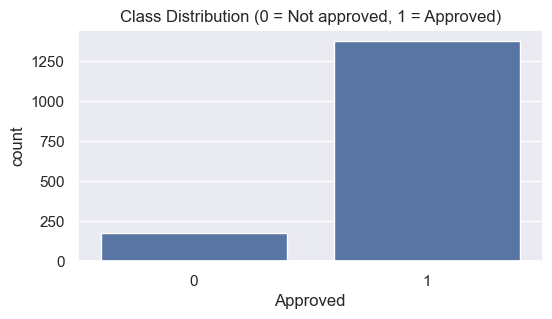

In [254]:
plt.figure(figsize=(6,3))
sns.countplot(x="Approved", data=df)
plt.title("Class Distribution (0 = Not approved, 1 = Approved)")
plt.show()

In [255]:
numerical_cols = ["CHILDREN","Annual_income","Family_Members","Age","Employment_years"]

categorical_cols = ["GENDER", "Car_Owner", "Propert_Owner","Type_Income","EDUCATION","Marital_status","Housing_type","Work_Phone",
                    "Phone", "EMAIL_ID", "Type_Occupation","Approved"]


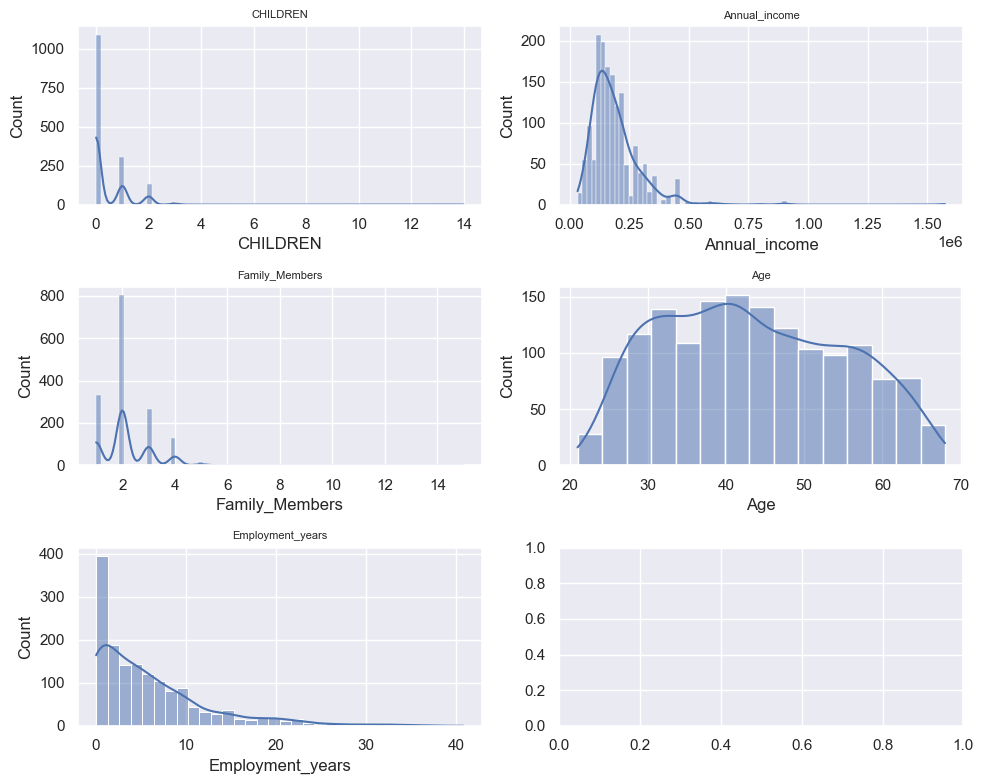

In [256]:
# histogram plot - distribution - for numerical features
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

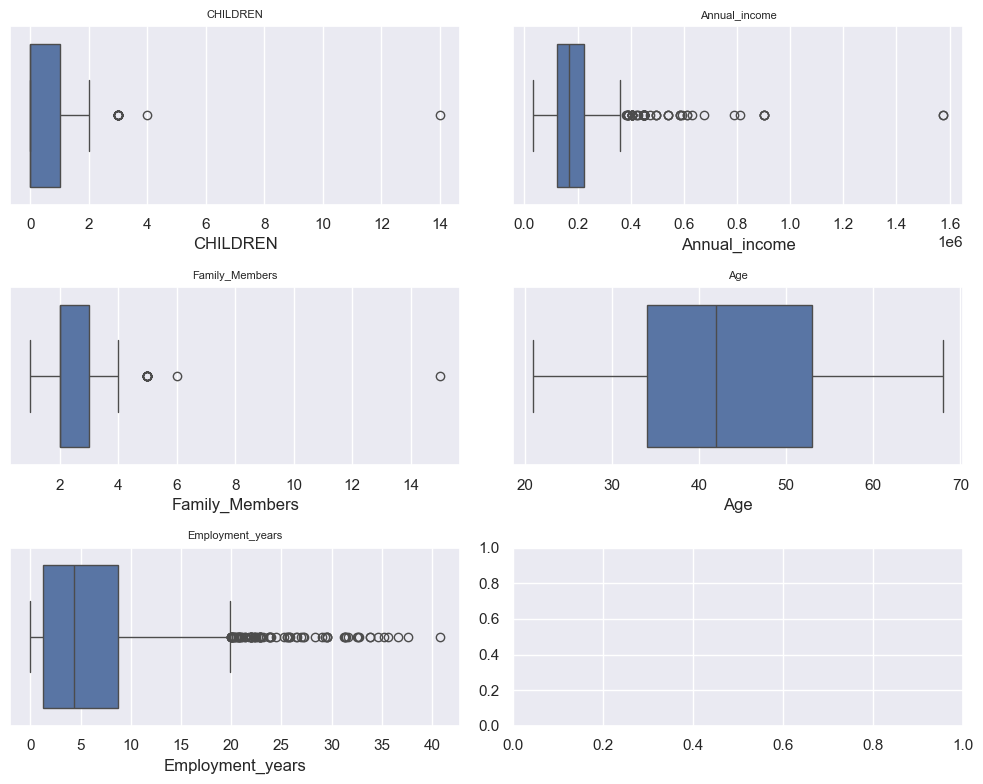

In [257]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

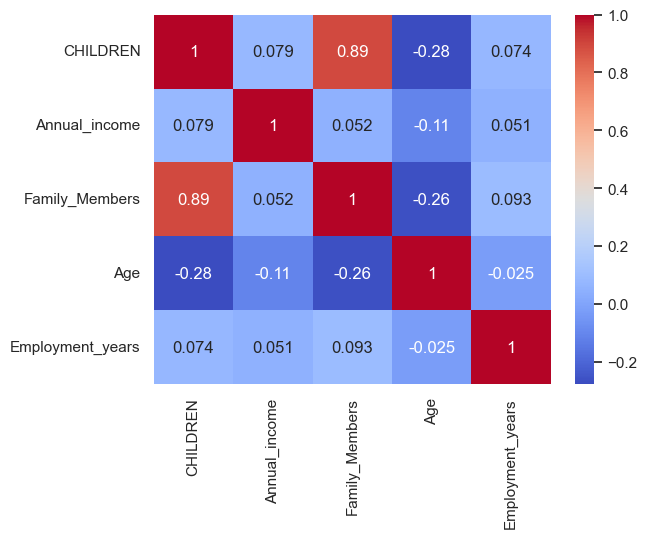

In [258]:
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [259]:
# highly corrleated features
df[['CHILDREN', 'Family_Members']].corr()

,CHILDREN,Family_Members
CHILDREN,1.000000,0.890248
Family_Members,0.890248,1.000000


Check which variable has more useful information for predicting your target.

In [260]:
df.groupby('CHILDREN')['Approved'].mean()

CHILDREN
0     0.884510
1     0.881967
2     0.910448
3     1.000000
4     0.000000
14    1.000000
Name: Approved, dtype: float64

In [261]:
df.groupby('Family_Members')['Approved'].mean()

Family_Members
1     0.883234
2     0.880299
3     0.891791
4     0.921260
5     1.000000
6     0.000000
15    1.000000
Name: Approved, dtype: float64

In [262]:
print(df.groupby('CHILDREN')['Approved'].agg(['count', 'mean']))
print(df.groupby('Family_Members')['Approved'].agg(['count', 'mean']))

          count      mean
CHILDREN                 
0          1091  0.884510
1           305  0.881967
2           134  0.910448
3            16  1.000000
4             1  0.000000
14            1  1.000000
                count      mean
Family_Members                 
1                 334  0.883234
2                 802  0.880299
3                 268  0.891791
4                 127  0.921260
5                  15  1.000000
6                   1  0.000000
15                  1  1.000000


In [263]:
# Family_members has a more meaningful distribution
df = df.drop(columns=['CHILDREN'])
numerical_cols.remove("CHILDREN")

In [264]:
df.duplicated().sum()

np.int64(164)

In [265]:
df = df.drop_duplicates()
df.shape

(1384, 16)

In [266]:
df.nunique()

GENDER                2
Car_Owner             2
Propert_Owner         2
Annual_income       115
Type_Income           4
EDUCATION             5
Marital_status        5
Housing_type          6
Work_Phone            2
Phone                 2
EMAIL_ID              2
Type_Occupation      19
Family_Members        7
Approved              2
Age                  48
Employment_years    230
dtype: int64

**Data Preprocessing**

In [267]:
X = df.drop('Approved', axis=1)
y = df['Approved']

In [268]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [269]:
print("Train shape:", X_train.shape)

print("Test shape:", X_test.shape)

Train shape: (1107, 15)
Test shape: (277, 15)


In [270]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

# numerical features - preprocessing steps
# imputers can be added in numerical transformer
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numerical features: ['GENDER', 'Car_Owner', 'Propert_Owner', 'Annual_income', 'Work_Phone', 'Phone', 'EMAIL_ID', 'Family_Members', 'Age', 'Employment_years']
Categorical features: ['Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Type_Occupation']


Baseline Model - Logistic Regression